## Compare how similar nPRF maps are to DAN maps

- maybe specifically the parietal patches of each 

In [16]:
import os.path as op
import numpy as np
import nibabel as nib

dataset ='dnumrisk' #'smile1'#
#bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'

net_folder = op.join( f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}', 'derivatives', 'networks_infomap_full_01')
nPRF_folder = op.join( f'/mnt_03/ds-{dataset}', 'derivatives', 'encoding_model.denoise')

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

260327-15:19:34,439 nipype.utils WARNING:
	 A newer version (1.11.0) of nipy/nipype is available. You are using 1.8.6


In [32]:
sub = '01'

net_of_interest = 5.0
pfmap = np.load(op.join(net_folder,f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
pfmap = pfmap.astype(float) 
pfmap[pfmap != net_of_interest] = np.nan
pfmap_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
pfmap_fsav5[mask] = pfmap

# nPRFmaps still in gifti format, but we can load them as numpy arrays with nibabel
nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub}', 'ses-1', 'func', f'sub-{sub}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub}', 'ses-1', 'func', f'sub-{sub}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

In [ ]:
combined_map = nPRFmap_fsav5
combined_map[pfmap_fsav5 != net_of_interest] = ?

In [ ]:
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = pfmap

In [29]:
import matplotlib.patches as mpatches
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])

grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity
cmap_ca = ListedColormap( np.vstack([grey, rgb]))

from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt

In [ ]:
## --> use pycortex (flatmaps - from VEM toolbox?) for plotting 
# --> can plot both maps at the same time with different color maps and transparencies.

In [38]:
combined_map = nPRFmap_fsav5.copy()
combined_map[pfmap_fsav5 != net_of_interest] = np.nan  # or 0 if you prefer

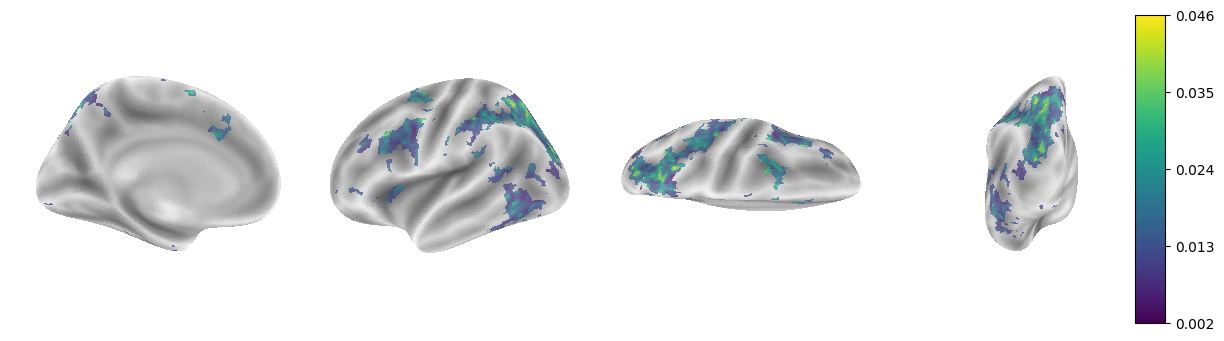

In [40]:
hemi_to_plot = 'L' # 'R'

fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior']
cmap = 'viridis' 

i_hemi_to_plot = 0 if hemi_to_plot == 'L' else 1  
combined_map_hemi = np.split(combined_map,2)[i_hemi_to_plot]

surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'posterior' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= combined_map_hemi, avg_method = 'median',# infl_right # pial_right
            view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            #vmin = 0, vmax=12,
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)